In [ ]:
# %%
# ==========================================
# CELL 1: DATA PROCESSING
# Run this ONCE to pull the API and load df_plot into memory
# ==========================================
import pandas as pd
import requests
from us import states

# 1. SETUP & API INIT
CENSUS_KEY = "YOUR CENSUS KEY HERE"

# 2. LOAD & CLEAN DATA
df_geo = pd.read_csv("GEOINFO2024.GEOINFO-Data.csv", skiprows=[1])
df_geo['AREALAND_SQMI'] = pd.to_numeric(df_geo['AREALAND_SQMI'])

# Direct API call to bypass the census library HTML metadata error
url = f"https://api.census.gov/data/2024/acs/acs1?get=NAME,B01001_001E&for=state:*&key={CENSUS_KEY}"
response = requests.get(url)
data = response.json()

df_pop = pd.DataFrame(data[1:], columns=data[0])
df_pop = df_pop.rename(columns={'NAME': 'state_name', 'B01001_001E': 'population'})
df_pop['population'] = pd.to_numeric(df_pop['population'])

# 3. MERGE & MAPPING
context_data = {
    'Alabama': {'response': 10.2, 'pvi': 15}, 'Alaska': {'response': 12.5, 'pvi': 8},
    'Arizona': {'response': 9.8, 'pvi': 2}, 'Arkansas': {'response': 11.1, 'pvi': 16},
    'California': {'response': 8.9, 'pvi': -13}, 'Colorado': {'response': 10.4, 'pvi': -4},
    'Connecticut': {'response': 8.1, 'pvi': -7}, 'Delaware': {'response': 8.5, 'pvi': -7},
    'Florida': {'response': 9.2, 'pvi': 3}, 'Georgia': {'response': 10.1, 'pvi': 3},
    'Hawaii': {'response': 11.5, 'pvi': -14}, 'Idaho': {'response': 13.2, 'pvi': 18},
    'Illinois': {'response': 9.5, 'pvi': -7}, 'Indiana': {'response': 10.8, 'pvi': 11},
    'Iowa': {'response': 11.9, 'pvi': 6}, 'Kansas': {'response': 12.1, 'pvi': 10},
    'Kentucky': {'response': 11.4, 'pvi': 16}, 'Louisiana': {'response': 10.7, 'pvi': 12},
    'Maine': {'response': 14.2, 'pvi': -2}, 'Maryland': {'response': 9.4, 'pvi': -14},
    'Massachusetts': {'response': 8.3, 'pvi': -15}, 'Michigan': {'response': 10.5, 'pvi': 1},
    'Minnesota': {'response': 12.4, 'pvi': -1}, 'Mississippi': {'response': 11.8, 'pvi': 11},
    'Missouri': {'response': 11.2, 'pvi': 10}, 'Montana': {'response': 15.1, 'pvi': 11},
    'Nebraska': {'response': 12.8, 'pvi': 13}, 'Nevada': {'response': 9.7, 'pvi': 1},
    'New Hampshire': {'response': 11.6, 'pvi': -1}, 'New Jersey': {'response': 7.9, 'pvi': -6},
    'New Mexico': {'response': 11.3, 'pvi': -3}, 'New York': {'response': 8.8, 'pvi': -10},
    'North Carolina': {'response': 10.9, 'pvi': 3}, 'North Dakota': {'response': 14.8, 'pvi': 20},
    'Ohio': {'response': 10.3, 'pvi': 6}, 'Oklahoma': {'response': 11.5, 'pvi': 20},
    'Oregon': {'response': 11.1, 'pvi': -6}, 'Pennsylvania': {'response': 10.6, 'pvi': 2},
    'Rhode Island': {'response': 7.5, 'pvi': -8}, 'South Carolina': {'response': 11.0, 'pvi': 8},
    'South Dakota': {'response': 14.5, 'pvi': 16}, 'Tennessee': {'response': 14.0, 'pvi': 14},
    'Texas': {'response': 10.2, 'pvi': 5}, 'Utah': {'response': 11.4, 'pvi': 13},
    'Vermont': {'response': 13.8, 'pvi': -16}, 'Virginia': {'response': 10.5, 'pvi': -3},
    'Washington': {'response': 10.9, 'pvi': -8}, 'West Virginia': {'response': 12.6, 'pvi': 22},
    'Wisconsin': {'response': 11.7, 'pvi': 2}, 'Wyoming': {'response': 16.2, 'pvi': 25}
}

df = pd.merge(df_pop, df_geo.rename(columns={'NAME': 'state_name'}), on='state_name')
df['pop_density'] = df['population'] / df['AREALAND_SQMI']
df['resp_time'] = df['state_name'].map(lambda x: context_data.get(x, {}).get('response'))
df['pvi_score'] = df['state_name'].map(lambda x: context_data.get(x, {}).get('pvi'))
df['state_abbr'] = df['state_name'].map(lambda x: states.lookup(x).abbr if states.lookup(x) else x)

state_list = [s.name for s in states.STATES]
df_plot = df[df['state_name'].isin(state_list)].sort_values('pop_density', ascending=False).reset_index()

# Assign numeric ranks (1 = highest density)
df_plot['density_rank'] = range(1, len(df_plot) + 1)
print("Data loaded and prepped successfully! Move to visualization cell.")

Data loaded and prepped successfully! Move to visualization cell.


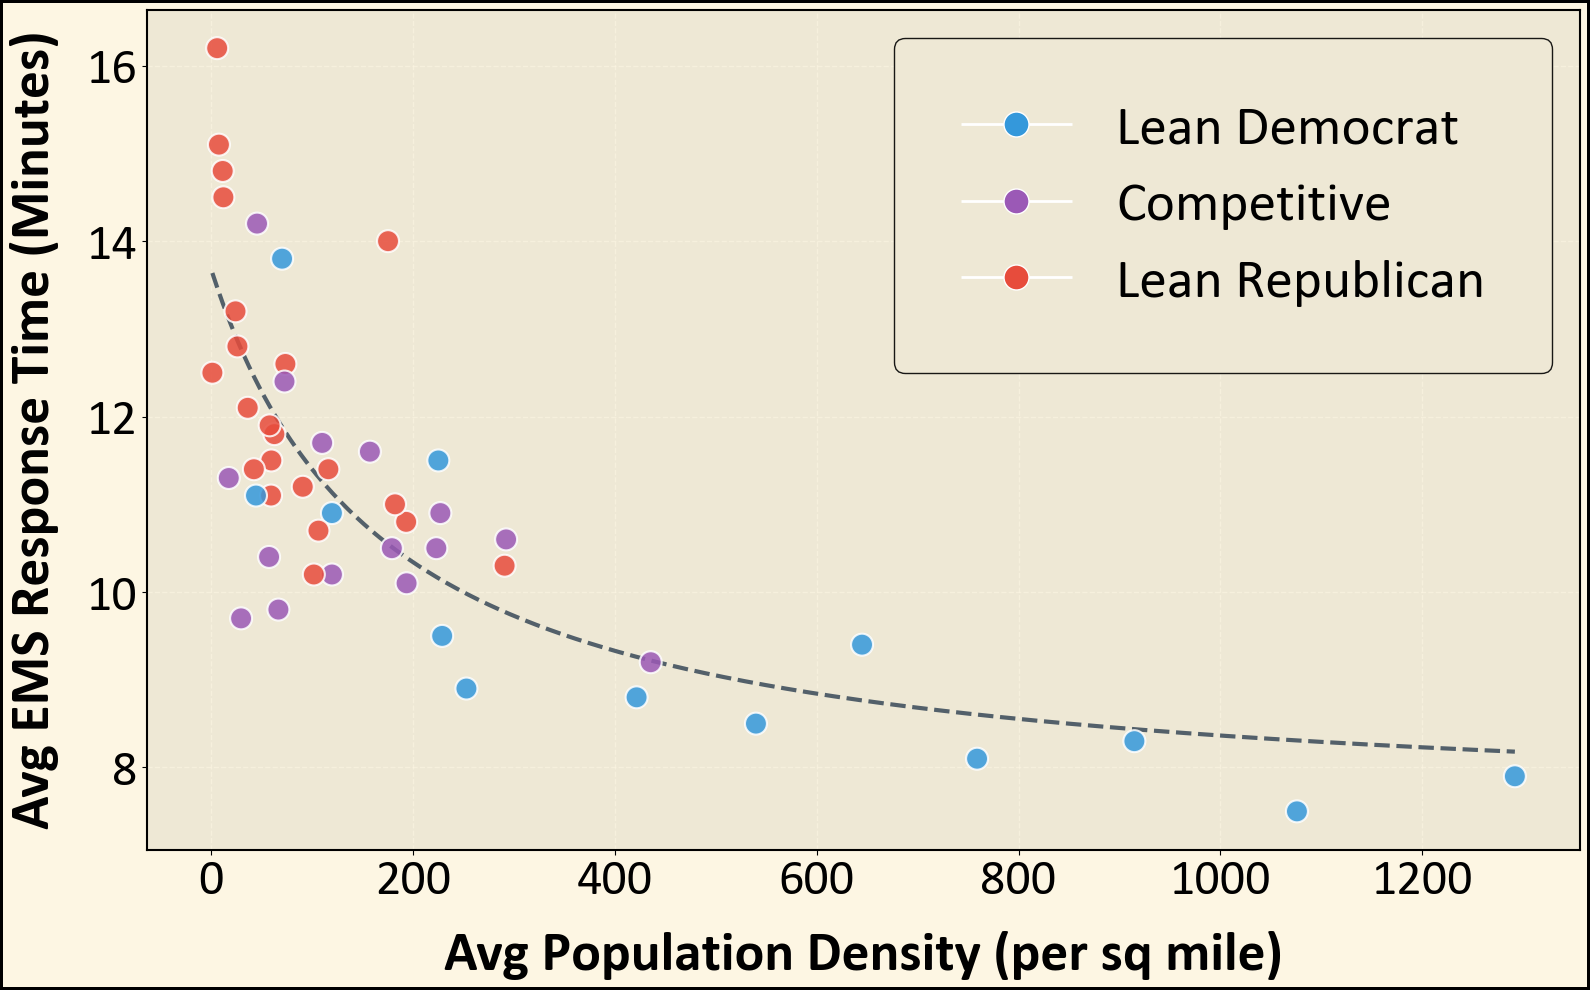

In [19]:
# ==========================================
# CELL 2: VISUALIZATION (Scatter Plot + Inverse Fit)
# Requires df_plot from Cell 1. 
# ==========================================
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy.optimize import curve_fit

# 1. APPLY BTT STYLING
plt.style.use(['Solarize_Light2', 'btt_style'])

# 2. RENDER CHART
fig, ax = plt.subplots(figsize=(16, 10))

# Map colors based on PVI score directly to the scatter points
colors = ['#e74c3c' if x > 5 else ('#3498db' if x < -5 else '#9b59b6') for x in df_plot['pvi_score']]

# --- INVERSE FUNCTION FIT ---
# Define the function: y = a / (x + b) + c
# This creates a steeper initial drop than exponential decay
def inverse_fit(x, a, b, c):
    return a / (x + b) + c

# Fit the curve 
# p0 provides initial guesses: scale (a), horizontal shift (b), and the baseline time floor (c)
popt, _ = curve_fit(inverse_fit, df_plot['pop_density'], df_plot['resp_time'], p0=(200, 50, 8))

# Generate smooth x values for the line
x_smooth = np.linspace(df_plot['pop_density'].min(), df_plot['pop_density'].max(), 500)
y_smooth = inverse_fit(x_smooth, *popt)

# Plot the new trendline (drawn under the scatter points)
ax.plot(x_smooth, y_smooth, color='#2c3e50', linestyle='--', linewidth=3, alpha=0.8, zorder=2)

# --- SCATTER PLOT ---
scatter = ax.scatter(df_plot['pop_density'], df_plot['resp_time'], 
                     c=colors, s=250, alpha=0.85, edgecolors='white', linewidth=1.5, zorder=3)

# --- AXIS FORMATTING ---
ax.set_xlabel('Avg Population Density (per sq mile)', fontsize=40, fontweight='bold', labelpad=20)
ax.set_ylabel('Avg EMS Response Time (Minutes)', fontsize=40, fontweight='bold', labelpad=20)
ax.tick_params(axis='both', which='major', labelsize=36)

# Grid for scannability
ax.grid(True, which='major', linestyle='--', alpha=0.6, zorder=0)

# --- LEGEND ---
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=18, label='Lean Democrat'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9b59b6', markersize=18, label='Competitive'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=18, label='Lean Republican')
]

ax.legend(handles=legend_elements, loc='upper right', fontsize=40, borderpad=1.2, framealpha=0.9, edgecolor='black')

# Force the figure border properties right before saving
fig.patch.set_edgecolor('black')
fig.patch.set_linewidth(3)

plt.tight_layout()
plt.show()
fig.savefig('final_scatter_inverse_fit.png', dpi=600, bbox_inches='tight')